In [ ]:
!pip install ultralytics roboflow

# Banana Classification using YOLO

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import glob
from collections import Counter
import random

from ultralytics import YOLO
from roboflow import Roboflow
from kaggle_secrets import UserSecretsClient

from google.colab.patches import cv2_imshow
from google.colab import userdata

## Problem Definition
- Task type: Classification
- Objective: Classify banana images into: freshripe, freshunripe, overripe, ripe, rotten, unripe
- Type: multiclass Classification

## Dataset + EDA

In [ ]:
user_secrets = UserSecretsClient()
rf = Roboflow(api_key=user_secrets.get_secret("ROBOFLOW_API_KEY"))
project = rf.workspace("chetan-sharma-n4cau").project("banana-ripeness-classification-a9hps")
version = project.version(3)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Banana-Ripeness-Classification-3 in folder:: 100%|██████████| 5639/5639 [00:00<00:00, 12030.06it/s]


In [ ]:
# data_path = '/content/License-Plate-Recognition-1'
data_path = '/kaggle/working/Banana-Ripeness-Classification-3'
train_path = os.path.join(data_path, 'train')
valid_path = os.path.join(data_path, 'valid')
test_path = os.path.join(data_path, 'test')
train_labels = os.path.join(train_path, 'labels')

image_dir, label_dir = f"{train_path}/images", f"{train_path}/labels"

In [ ]:
def get_class_distribution(path):
    counter = Counter()

    train_path = os.path.join(path, "train")

    for cls in os.listdir(train_path):
        cls_path = os.path.join(train_path, cls)
        counter[cls] = len(os.listdir(cls_path))

    return counter

dist = get_class_distribution(data_path)
print(dist)

Counter({'rotten': 1340, 'overripe': 783, 'freshripe': 704, 'freshunripe': 501, 'ripe': 470, 'unripe': 133})


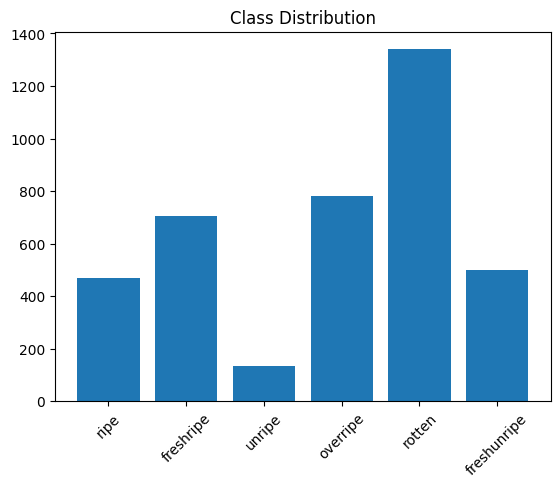

In [ ]:
plt.bar(dist.keys(), dist.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

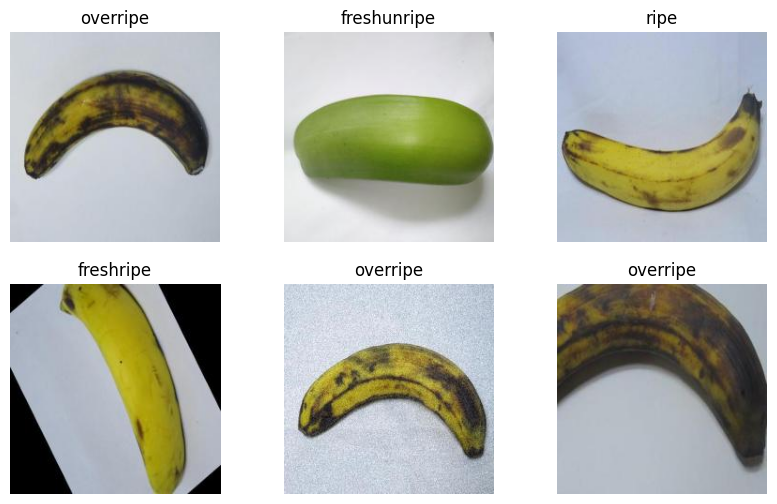

In [ ]:
def show_samples(path, n=6):
    train_path = os.path.join(path, "train")

    classes = os.listdir(train_path)

    plt.figure(figsize=(10,6))

    for i in range(n):
        cls = random.choice(classes)
        img_name = random.choice(os.listdir(os.path.join(train_path, cls)))
        img_path = os.path.join(train_path, cls, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

    plt.show()

show_samples(data_path)

### EDA Findings
- The dataset contains 6 classes: `rotten`, `overripe`, `freshripe`, `freshunripe`, `ripe`, and `unripe`.
- The class distribution is imbalanced, with 'rotten' being the most frequent class (1340 images) and 'unripe' being the least frequent (133 images).
- Sample images reveal varying visual characteristics for each ripeness stage.

## Preprocessing + Augmentation
- auto scaling done in robo flow
- images are resized to 640*640 in roboflow

## Model + Config

- Model: yolo 11 (ultralytics)

>Why YOLO?
> - Real-time classification
> - Good balance of speed & accuracy

In [ ]:
model = YOLO("yolo11n-cls.pt")

## Training

In [ ]:
results = model.train(
    data=data_path,
    epochs=20,
    imgsz=224,
    batch=32,
    device=0,
    workers=4
)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Banana-Ripeness-Classification-3, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

## Evaluation and visualization

Text(0.5, 1.0, 'Training Curves')

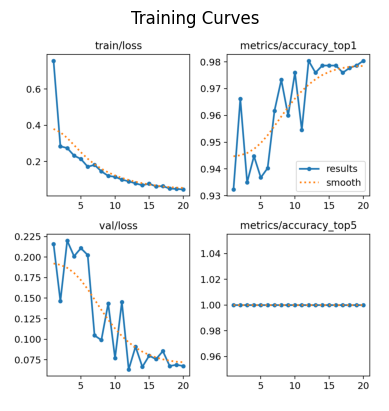

In [ ]:
img = plt.imread("runs/classify/train/results.png")
plt.imshow(img)
plt.axis("off")
plt.title("Training Curves")

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-cls summary (fused): 47 layers, 1,533,710 parameters, 0 gradients, 3.2 GFLOPs
train: /kaggle/working/Banana-Ripeness-Classification-3/train... found 3931 images in 6 classes ✅ 
val: /kaggle/working/Banana-Ripeness-Classification-3/valid... found 1123 images in 6 classes ✅ 
test: /kaggle/working/Banana-Ripeness-Classification-3/test... found 562 images in 6 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 181.8±81.3 MB/s, size: 5.4 KB)
val: Scanning /kaggle/working/Banana-Ripeness-Classification-3/valid... 1123 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1123/1123 392.5Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 71/71 50.0it/s 1.4s0.0s
                   all       0.98          1
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object wit

In [ ]:
print("Top-1 Accuracy:", metrics.top1)
print("Top-5 Accuracy:", metrics.top5)

Top-1 Accuracy: 0.9804096221923828
Top-5 Accuracy: 1.0


In [ ]:
metrics.confusion_matrix.plot(save_dir=".")

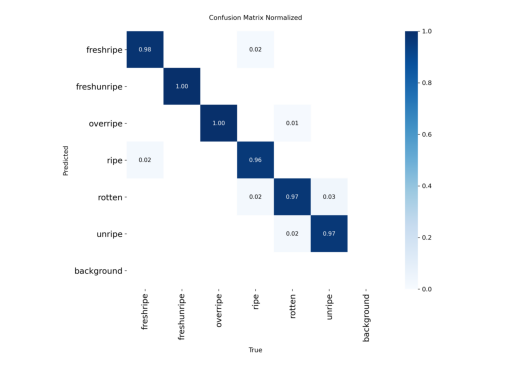

In [ ]:
img = cv2.imread('confusion_matrix_normalized.png')

if img is not None:
  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.show()

## Model TestingPrediction

In [ ]:
image_paths = glob.glob(f"{test_path}/*/*.jpg")

results = model.predict(
    source=image_paths,
    conf=0.25
)


0: 224x224 ripe 1.00, freshripe 0.00, overripe 0.00, rotten 0.00, unripe 0.00, 0.3ms
1: 224x224 ripe 0.99, overripe 0.01, unripe 0.00, rotten 0.00, freshripe 0.00, 0.3ms
2: 224x224 ripe 1.00, overripe 0.00, freshripe 0.00, rotten 0.00, unripe 0.00, 0.3ms
3: 224x224 ripe 1.00, overripe 0.00, freshripe 0.00, rotten 0.00, unripe 0.00, 0.3ms
4: 224x224 ripe 0.99, freshripe 0.01, overripe 0.00, unripe 0.00, rotten 0.00, 0.3ms
5: 224x224 ripe 0.68, freshripe 0.28, rotten 0.03, overripe 0.01, unripe 0.00, 0.3ms
6: 224x224 ripe 1.00, overripe 0.00, freshripe 0.00, unripe 0.00, rotten 0.00, 0.3ms
7: 224x224 ripe 1.00, freshripe 0.00, overripe 0.00, rotten 0.00, unripe 0.00, 0.3ms
8: 224x224 ripe 0.99, freshripe 0.01, rotten 0.00, overripe 0.00, unripe 0.00, 0.3ms
9: 224x224 ripe 1.00, overripe 0.00, freshripe 0.00, rotten 0.00, unripe 0.00, 0.3ms
10: 224x224 ripe 1.00, freshripe 0.00, overripe 0.00, rotten 0.00, unripe 0.00, 0.3ms
11: 224x224 ripe 0.99, rotten 0.01, overripe 0.00, freshripe 0.

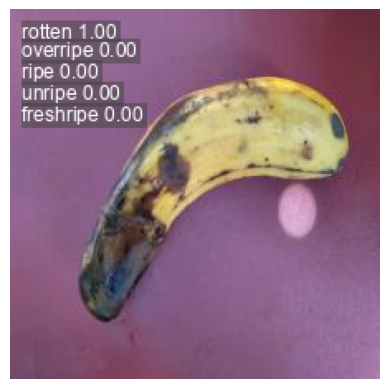

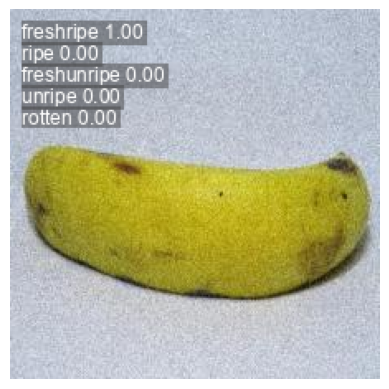

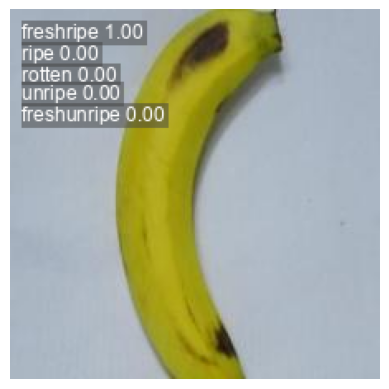

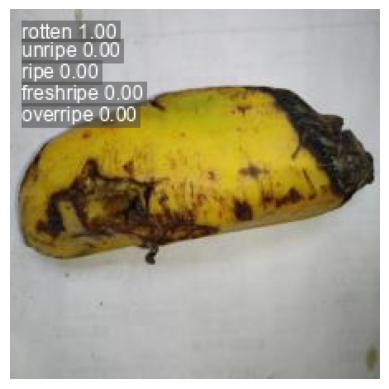

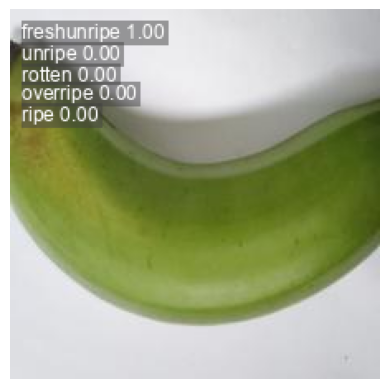

In [ ]:
samples = random.sample(results, 5)

for r in samples:
    img = r.plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
# single img testing
img_path = os.path.join(data_path, "test/ripe", os.listdir(os.path.join(data_path, "test/ripe"))[0])

result = model.predict(img_path)
print(result[0].probs)


image 1/1 /kaggle/working/Banana-Ripeness-Classification-3/test/ripe/musa-acuminata-banana-e4d2aaee-394a-11ec-ac9d-d8c4975e38aa_jpg.rf.1f9f8d4c387d86c88b5c7084d0379d95.jpg: 224x224 ripe 1.00, freshripe 0.00, overripe 0.00, rotten 0.00, unripe 0.00, 5.6ms
Speed: 1.9ms preprocess, 5.6ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
ultralytics.engine.results.Probs object with attributes:

data: tensor([8.4752e-05, 1.5984e-08, 4.6766e-06, 9.9991e-01, 8.6254e-07, 6.5608e-07], device='cuda:0')
orig_shape: None
shape: torch.Size([6])
top1: 3
top1conf: tensor(0.9999, device='cuda:0')
top5: [3, 0, 2, 4, 5]
top5conf: tensor([9.9991e-01, 8.4752e-05, 4.6766e-06, 8.6254e-07, 6.5608e-07], device='cuda:0')


### Inference

In [ ]:
model = YOLO("runs/classify/train/weights/best.pt")

In [ ]:
model.save('yolo_banana_classification.pt')
model.export(format="onnx")

## Conclusion

- The YOLO11n-cls model was successfully trained for 20 epochs on the banana ripeness dataset.
- The model achieved a Top-1 Accuracy of 0.9804 and a Top-5 Accuracy of 1.0 on the validation set, indicating strong performance.